# Análisis de Datos del Banco Mundial con Python

Este notebook muestra cómo descargar, manipular y analizar datos del Banco Mundial utilizando la librería `wbdata` en Python.

## 1. Instalación de Librerías

Antes de empezar, necesitas instalar las librerías necesarias. Abre una terminal o Anaconda Prompt y ejecuta los siguientes comandos:

```bash
conda install wbdata pandas numpy
```
Si `conda` no funciona, puedes intentarlo con `pip`:
```bash
pip install wbdata pandas numpy
```

In [3]:
!pip install wbdata

Defaulting to user installation because normal site-packages is not writeable


## 2. Importar Librerías

Importamos las librerías que acabamos de instalar para poder usarlas en nuestro script.

In [5]:
import wbdata
import pandas as pd
import numpy as np
import os

## 3. Configurar el Directorio de Trabajo

Es una buena práctica establecer un directorio de trabajo. Esto le dice a Python dónde guardar archivos (como los CSV que exportaremos más adelante) y dónde buscarlos. 

**Nota:** Reemplaza la ruta del ejemplo con la ruta a tu propia carpeta de proyectos.

In [7]:
# Cambia la siguiente ruta por la de tu carpeta de trabajo
# Ejemplo para Windows:
# os.chdir("C:/Users/TuUsuario/Documents/MiProyecto")
# Ejemplo para Mac/Linux:
# os.chdir("/Users/TuUsuario/Documents/MiProyecto")

## 4. Explorar Indicadores y Países

La librería `wbdata` tiene funciones para explorar las bases de datos, temas, países e indicadores disponibles. Puedes descomentar y ejecutar las siguientes líneas para ver las opciones.

In [9]:
# wbdata.get_source()       # Muestra las diferentes fuentes de datos
# wbdata.get_topic()        # Muestra los temas disponibles
# wbdata.get_country()      # Muestra una lista de todos los países y sus códigos
# wbdata.search_indicators("GDP per capita") # Busca indicadores relacionados con un término

## 5. Seleccionar Países e Indicadores

Primero, creamos una lista con los códigos de los países que nos interesan. Después, definimos un diccionario donde cada clave es el código del indicador del Banco Mundial y el valor es el nombre que le daremos a esa columna en nuestro DataFrame.

In [11]:
# Creamos una lista de Python con los países para los que queremos descargar datos.
# Usa el comando wbdata.get_country() para ver la lista de abreviaturas de países.
selcountries = ['ARG', 'BRA', 'CHL', 'CUB', 'MEX', 'PER', 'VEN', 'USA','ESP']

# Creamos un diccionario de Python con los identificadores de las variables de wbdata que nos interesan,
# asignando a cada una un nombre más sencillo.
lifeQualInd = {
    "NY.GDP.PCAP.PP.KD": "gdppc",
    "NY.GNP.PCAP.PP.CD": 'gnipc',
    "FP.CPI.TOTL.ZG": "inflation",
    "SE.PRM.CUAT.ZS": "educAtt_prim_25+",
    "SN.ITK.DEFC.ZS": "preval_undernour",
    "SM.POP.NETM": "netMig",
    "SP.DYN.LE00.IN": "life_exp",
    "SE.ADT.LITR.ZS": "literacyRate",
    "1.1_ACCESS.ELECTRICITY.TOT": "electAccess",
    "SP.POP.TOTL": "totalpop",
    "SP.URB.TOTL": "urbanpop"
}

# Asignamos el diccionario a una nueva variable para mayor claridad
indicators = lifeQualInd

## 6. Descargar los Datos

Usamos la función `wbdata.get_dataframe` para descargar los datos de los países e indicadores seleccionados. El resultado se almacena en un DataFrame de `pandas`.

In [13]:
df = wbdata.get_dataframe(indicators, country=selcountries)
df

gdppc  gnipc  inflation  educAtt_prim_25+  \
country       date                                              
Argentina     1960    NaN    NaN        NaN               NaN   
              1961    NaN    NaN        NaN               NaN   
              1962    NaN    NaN        NaN               NaN   
              1963    NaN    NaN        NaN               NaN   
              1964    NaN    NaN        NaN               NaN   
...                   ...    ...        ...               ...   
Venezuela, RB 2020    NaN    NaN        NaN               NaN   
              2021    NaN    NaN        NaN               NaN   
              2022    NaN    NaN        NaN               NaN   
              2023    NaN    NaN        NaN               NaN   
              2024    NaN    NaN        NaN               NaN   

                    preval_undernour    netMig  life_exp  literacyRate  \
country       date                                                       
Argentina     1960               NaN   20387.0    64.242           NaN   
              1961               NaN   26322.0    64.631           NaN   
              1962               NaN   31449.0    64.618           NaN   
              1963               NaN   32866.0    64.855           NaN   
              1964               NaN   34530.0    64.816           NaN   
...                              ...       ...       ...           ...   
Venezuela, RB 2020              22.2 -524649.0    72.369           NaN   
              2021              20.0 -332936.0    71.536           NaN   
              2022              17.6 -141107.0    72.566     97.599998   
              2023               NaN -112899.0    72.514           NaN   
              2024               NaN -105297.0       NaN           NaN   

                    electAccess    totalpop    urbanpop  
country       date                                       
Argentina     1960          NaN  20386045.0  15006372.0  
              1961          NaN  20726276.0  15382420.0  
              1962          NaN  21072538.0  15755304.0  
              1963          NaN  21421705.0  16132472.0  
              1964          NaN  21769453.0  16510824.0  
...                         ...         ...         ...  
Venezuela, RB 2020          NaN  28444077.0  25110147.0  
              2021          NaN  28237826.0  24941060.0  
              2022          NaN  28213017.0  24934100.0  
              2023          NaN  28300854.0  25028709.0  
              2024          NaN  28405543.0  25140326.0  

[585 rows x 11 columns]

## 7. Inspección Inicial del DataFrame

Una vez que tenemos los datos, es fundamental explorarlos para entender su estructura, ver las primeras y últimas filas, obtener un resumen estadístico, etc. Descomenta y ejecuta las siguientes funciones para inspeccionar el DataFrame `df`.

In [15]:
# df.head()          # Muestra las primeras 5 filas
# df.tail()          # Muestra las últimas 5 filas
# df.info()          # Muestra un resumen técnico (tipos de datos, valores nulos)
# df.columns         # Muestra los nombres de las columnas
# df.describe()      # Muestra estadísticas descriptivas (media, desviación estándar, etc.)

## 8. Manipulación de Datos

A menudo, necesitamos crear nuevas variables o transformar las existentes para nuestro análisis.

### Crear nuevas columnas

Aquí creamos una nueva columna `pcturb` que calcula el porcentaje de la población que vive en áreas urbanas.

In [18]:
df['pcturb'] = df['urbanpop'] / df['totalpop'] * 100

### Mover el índice a columnas

Por defecto, `wbdata` usa `country` y `date` como índices del DataFrame. Para poder filtrar y ordenar por estas variables más fácilmente, las convertimos en columnas regulares. Creamos una copia del DataFrame original para no modificarlo.

In [20]:
df2 = df.copy()
df2.reset_index(inplace=True)
df2

,country,date,gdppc,gnipc,inflation,educAtt_prim_25+,preval_undernour,netMig,life_exp,literacyRate,electAccess,totalpop,urbanpop,pcturb
0,Argentina,1960,NaN,NaN,NaN,NaN,NaN,20387.0,64.242,NaN,NaN,20386045.0,15006372.0,73.611002
1,Argentina,1961,NaN,NaN,NaN,NaN,NaN,26322.0,64.631,NaN,NaN,20726276.0,15382420.0,74.216999
2,Argentina,1962,NaN,NaN,NaN,NaN,NaN,31449.0,64.618,NaN,NaN,21072538.0,15755304.0,74.766998
3,Argentina,1963,NaN,NaN,NaN,NaN,NaN,32866.0,64.855,NaN,NaN,21421705.0,16132472.0,75.309001
4,Argentina,1964,NaN,NaN,NaN,NaN,NaN,34530.0,64.816,NaN,NaN,21769453.0,16510824.0,75.844000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,"Venezuela, RB",2020,NaN,NaN,NaN,NaN,22.2,-524649.0,72.369,NaN,NaN,28444077.0,25110147.0,88.279001
581,"Venezuela, RB",2021,NaN,NaN,NaN,NaN,20.0,-332936.0,71.536,NaN,NaN,28237826.0,24941060.0,88.325001
582,"Venezuela, RB",2022,NaN,NaN,NaN,NaN,17.6,-141107.0,72.566,97.599998,NaN,28213017.0,24934100.0,88.377999
583,"Venezuela, RB",2023,NaN,NaN,NaN,NaN,NaN,-112899.0,72.514,NaN,NaN,28300854.0,25028709.0,88.437999


## 9. Filtrado y Selección de Datos

Ahora podemos seleccionar subconjuntos de datos que cumplan ciertas condiciones.

### Seleccionar por año

Primero, nos aseguramos de que la columna 'date' sea de tipo numérico para poder hacer comparaciones. Luego, filtramos para quedarnos solo con los años entre 2014 y 2016.

In [23]:
df2['date'] = pd.to_numeric(df2['date']) # Convertimos la columna 'date' a tipo numérico
df_selyrs = df2[(df2['date'] >= 2014) & (df2['date'] <= 2024)]

df2016 = df2[df2['date'] == 2016]
df2016

,country,date,gdppc,gnipc,inflation,educAtt_prim_25+,preval_undernour,netMig,life_exp,literacyRate,electAccess,totalpop,urbanpop,pcturb
56,Argentina,2016,27802.105720,19660.0,NaN,NaN,3.0,5215.0,76.105000,NaN,100.000000,43900313.0,40224540.0,91.627000
121,Brazil,2016,17620.927243,14010.0,8.739144,81.480003,2.5,-92989.0,75.081000,93.0,100.000000,203218114.0,174852930.0,86.042000
186,Chile,2016,27958.728500,22610.0,3.786194,87.211418,3.2,135864.0,80.295000,NaN,100.000000,18267221.0,15969570.0,87.422000
251,Cuba,2016,NaN,NaN,NaN,NaN,2.5,-24146.0,77.571000,NaN,100.000000,11265612.0,8666635.0,76.929997
316,Mexico,2016,21578.263355,19580.0,2.821708,79.230003,3.7,-304472.0,74.376000,95.0,100.000000,122251351.0,97283958.0,79.577000
381,Peru,2016,14917.448947,11570.0,3.557177,69.959999,6.4,96740.0,75.951000,94.0,94.851746,30866494.0,23933571.0,77.539001
446,Spain,2016,44274.667615,37670.0,-0.202598,91.120003,2.5,106474.0,83.329268,98.0,100.000000,46458139.0,37092178.0,79.840000
511,United States,2016,65017.654963,58690.0,1.261583,98.879997,2.5,1889129.0,78.539024,NaN,100.000000,324353340.0,265522131.0,81.862000
576,"Venezuela, RB",2016,NaN,NaN,254.948535,92.709999,17.2,-283270.0,72.002000,97.0,99.603836,30765720.0,27124597.0,88.165000


### Seleccionar por país

Filtramos para obtener los datos únicamente de España, México, Estados Unidos y Brasil.

In [25]:
df_spain = df2[df2['country'].isin(['Spain'])]
df_spain = df_spain.set_index('date')
print(df_spain.head())

     country  gdppc  gnipc  inflation  educAtt_prim_25+  preval_undernour  \
date                                                                        
1960   Spain    NaN    NaN   1.177771               NaN               NaN   
1961   Spain    NaN    NaN   0.809253               NaN               NaN   
1962   Spain    NaN    NaN   5.706477               NaN               NaN   
1963   Spain    NaN    NaN   8.743698               NaN               NaN   
1964   Spain    NaN    NaN   6.979247               NaN               NaN   

        netMig   life_exp  literacyRate  electAccess    totalpop    urbanpop  \
date                                                                           
1960 -154869.0  69.109268           NaN          NaN  30455000.0  17227480.0   
1961  -46517.0  69.480488           NaN          NaN  30739250.0  17614512.0   
1962  -45211.0  69.519024           NaN          NaN  31023366.0  18089104.0   
1963  -44446.0  69.681220           NaN          NaN  312966

<Axes: xlabel='date'>

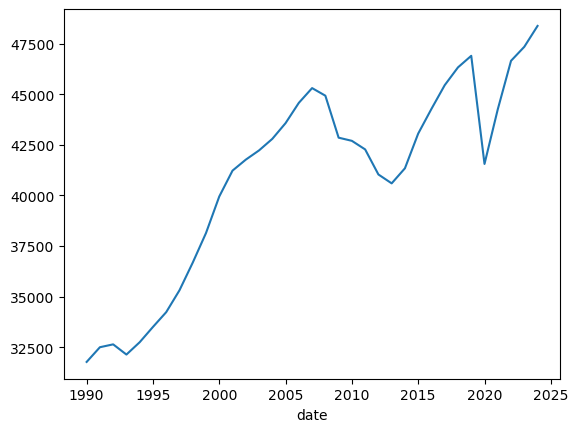

In [26]:
df_spain['gdppc'].plot()

### Seleccionar por columnas

Creamos un nuevo DataFrame que contiene solo las columnas de país, fecha y PIB per cápita.

In [28]:
gdpOnly = df2[['country', 'date', 'gdppc']]
gdpOnly

,country,date,gdppc
0,Argentina,1960,NaN
1,Argentina,1961,NaN
2,Argentina,1962,NaN
3,Argentina,1963,NaN
4,Argentina,1964,NaN
...,...,...,...
580,"Venezuela, RB",2020,NaN
581,"Venezuela, RB",2021,NaN
582,"Venezuela, RB",2022,NaN
583,"Venezuela, RB",2023,NaN


## 10. Manejo de Datos Faltantes (NaN)

Es muy común que los conjuntos de datos tengan valores faltantes. Es importante identificarlos y decidir cómo tratarlos.

### Verificar qué datos faltan

Podemos filtrar el DataFrame para ver qué filas tienen valores nulos (`NaN`) en columnas específicas y contar cuántos casos hay por país o año.

In [31]:
dfnogdp = df2[df2['gdppc'].isnull()]
# dfnogdp['country'].value_counts() # Contar valores nulos de 'gdppc' por país

dfnolfexp = df2[df2['life_exp'].isnull()]
dfnolfexp['country'].value_counts() # Contar valores nulos de 'life_exp' por país

country
Argentina        1
Brazil           1
Chile            1
Cuba             1
Mexico           1
Peru             1
Spain            1
United States    1
Venezuela, RB    1
Name: count, dtype: int64

### Eliminar filas con datos faltantes

Una estrategia común es eliminar las filas que tienen valores faltantes en columnas clave. `dropna()` nos permite hacer esto.

In [33]:
df_2023 = df2[df2['date'] == 2023]

In [34]:
df_haslfexp = df_2023.dropna(subset=['life_exp'])
df_hasgdp = df_2023.dropna(subset=['gdppc'])
df_hasgdp_and_haslfexp= df_2023.dropna(subset=['gdppc','life_exp'])

In [35]:
df = df_hasgdp_and_haslfexp

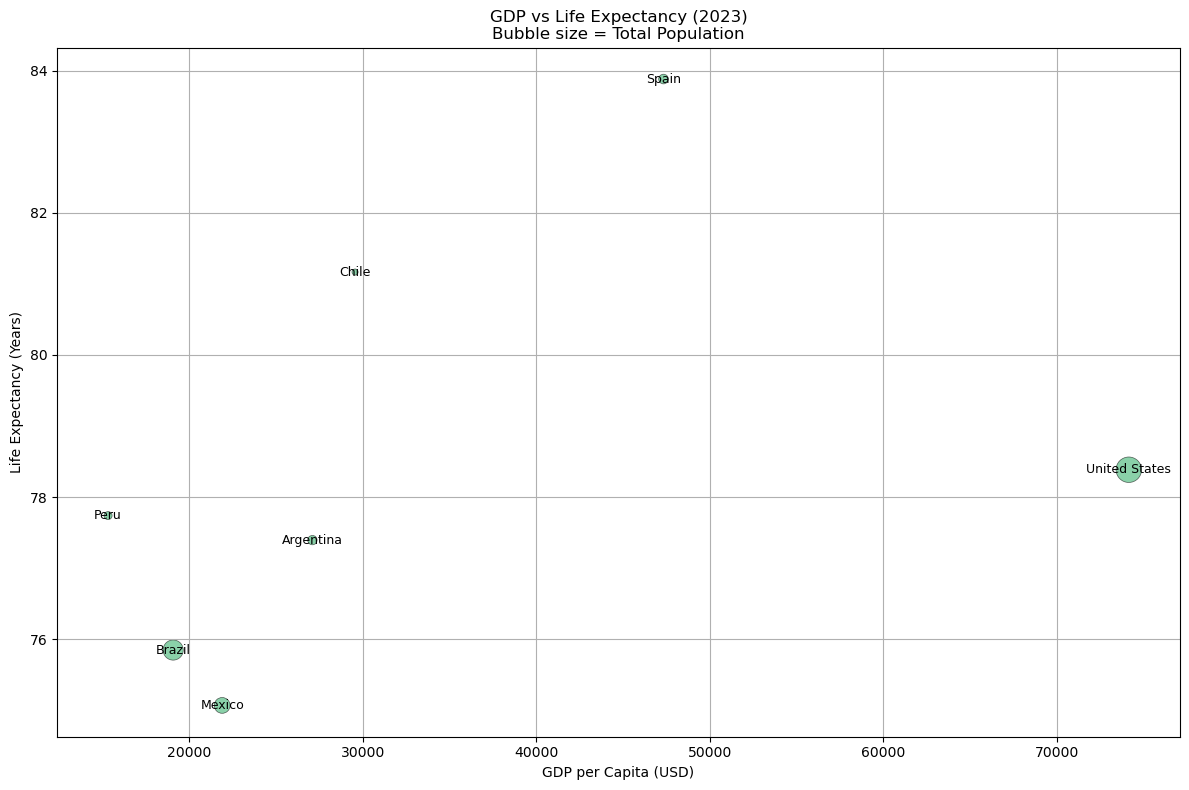

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.scatter(
    df['gdppc'],
    df['life_exp'],
    s=df['totalpop'] / 1e6,  # Escalar tamaño de burbuja
    alpha=0.6,
    c='mediumseagreen',
    edgecolors='black',
    linewidth=0.5
)

# Añadir etiquetas de país
for i, row in df.iterrows():
    plt.text(row['gdppc'], row['life_exp'], row['country'], fontsize=9, ha='center', va='center')

plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Life Expectancy (Years)')
plt.title('GDP vs Life Expectancy (2023)\nBubble size = Total Population')
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Ordenar Datos

Podemos ordenar el DataFrame basándonos en los valores de una o más columnas. Aquí ordenamos los datos de 2016 según la esperanza de vida.

In [41]:
# Ordenar por esperanza de vida de menor a mayor
df2016.sort_values(by='life_exp')

# Ordenar por esperanza de vida de mayor a menor
df2016.sort_values(by='life_exp', ascending=False)

,country,date,gdppc,gnipc,inflation,educAtt_prim_25+,preval_undernour,netMig,life_exp,literacyRate,electAccess,totalpop,urbanpop,pcturb
446,Spain,2016,44274.667615,37670.0,-0.202598,91.120003,2.5,106474.0,83.329268,98.0,100.000000,46458139.0,37092178.0,79.840000
186,Chile,2016,27958.728500,22610.0,3.786194,87.211418,3.2,135864.0,80.295000,NaN,100.000000,18267221.0,15969570.0,87.422000
511,United States,2016,65017.654963,58690.0,1.261583,98.879997,2.5,1889129.0,78.539024,NaN,100.000000,324353340.0,265522131.0,81.862000
251,Cuba,2016,NaN,NaN,NaN,NaN,2.5,-24146.0,77.571000,NaN,100.000000,11265612.0,8666635.0,76.929997
56,Argentina,2016,27802.105720,19660.0,NaN,NaN,3.0,5215.0,76.105000,NaN,100.000000,43900313.0,40224540.0,91.627000
381,Peru,2016,14917.448947,11570.0,3.557177,69.959999,6.4,96740.0,75.951000,94.0,94.851746,30866494.0,23933571.0,77.539001
121,Brazil,2016,17620.927243,14010.0,8.739144,81.480003,2.5,-92989.0,75.081000,93.0,100.000000,203218114.0,174852930.0,86.042000
316,Mexico,2016,21578.263355,19580.0,2.821708,79.230003,3.7,-304472.0,74.376000,95.0,100.000000,122251351.0,97283958.0,79.577000
576,"Venezuela, RB",2016,NaN,NaN,254.948535,92.709999,17.2,-283270.0,72.002000,97.0,99.603836,30765720.0,27124597.0,88.165000


## 12. Exportar Datos a CSV

Una vez que hemos limpiado y preparado nuestro DataFrame, podemos guardarlo como un archivo CSV para usarlo más tarde sin tener que repetir todos los pasos de descarga y limpieza.

In [44]:
df_haslfexp.to_csv('LatAm_US_lifeexp_to2016.csv')

Claro, Manoel. Aquí tienes una descripción detallada de un ejercicio ideal para estudiantes de análisis de datos, economía o ciencia política, que combina programación en Python con interpretación de indicadores socioeconómicos:

---

### 🧠 **Ejercicio: Visualización de Indicadores Socioeconómicos en Europa (2023)**

**Objetivo:**  
Los alumnos deberán generar una gráfica de dispersión (scatter plot) que relacione el **PIB per cápita** con la **esperanza de vida** para países europeos en el año **2023**, donde el **tamaño de cada punto** represente la **población total** del país.

---

### 🛠️ **Instrucciones técnicas**

1. **Instalar librerías necesarias:**
   ```bash
   pip install wbdata pandas matplotlib
   ```

2. **Seleccionar indicadores del Banco Mundial:**
   - PIB per cápita: `NY.GDP.PCAP.CD`
   - Esperanza de vida: `SP.DYN.LE00.IN`
   - Población total: `SP.POP.TOTL`

3. **Filtrar países europeos:**
   - Usar `wbdata.get_country()` para obtener la lista de países.
   - Filtrar por región `'Europe & Central Asia'` o por códigos ISO manualmente.

4. **Descargar datos para el año 2023.**

5. **Limpiar el DataFrame:**
   - Eliminar filas con valores nulos.
   - Asegurarse de que los datos estén alineados por país y año.

6. **Crear el gráfico:**
   - Eje X: PIB per cápita.
   - Eje Y: Esperanza de vida.
   - Tamaño de burbuja: población total.
   - Etiquetas opcionales: nombre del país.

---

### 📊 **Aspectos a analizar en el gráfico**

- ¿Existe una correlación entre PIB per cápita y esperanza de vida?
- ¿Qué países se destacan por tener alta esperanza de vida con bajo PIB?
- ¿Cómo influye la población en la visualización?
- ¿Qué patrones regionales se observan?

---

### 🎯 **Competencias desarrolladas**

- Uso de APIs para obtener datos reales.
- Limpieza y manipulación de datos con `pandas`.
- Visualización efectiva con `matplotlib`.
- Interpretación crítica de indicadores sociales y económicos.


In [47]:
import wbdata
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Fecha objetivo
fecha = datetime.datetime(2023, 1, 1)

# Lista de países europeos (abreviaturas ISO)
european_countries = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA',
    'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'MLT',
    'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE', 'CHE'
]

# Indicadores del Banco Mundial
indicators = {
    "NY.GDP.PCAP.PP.KD": "gdppc",          # PIB per cápita ajustado por paridad
    "SP.DYN.LE00.IN": "life_exp",          # Esperanza de vida
    "SP.POP.TOTL": "totalpop"              # Población total
}

# Descargar datos
df = wbdata.get_dataframe(indicators, country=european_countries)

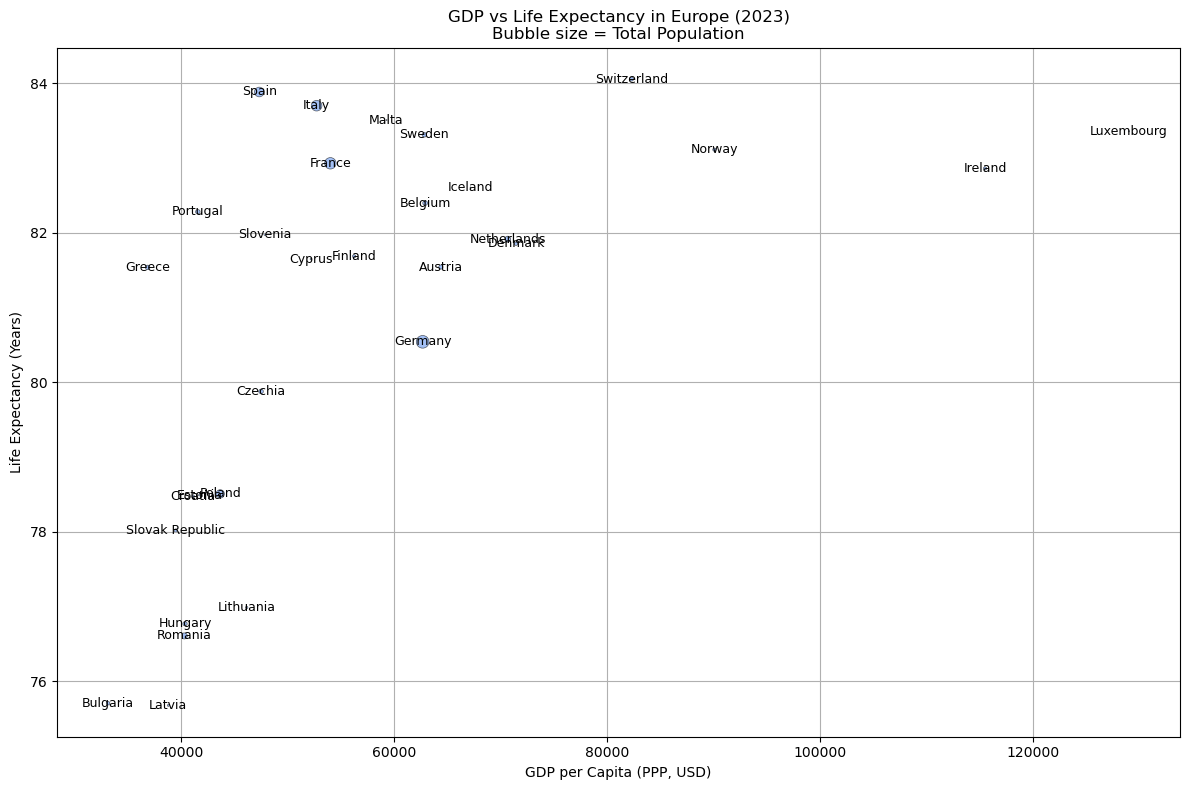

In [52]:
# Filtrar por año 2023
df_2023 = df[df.index.get_level_values('date') == '2023'].reset_index()

# Eliminar filas con datos faltantes
df_clean = df_2023.dropna(subset=['gdppc', 'life_exp', 'totalpop'])

# Crear gráfico de dispersión
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(
    df_clean['gdppc'],
    df_clean['life_exp'],
    s=df_clean['totalpop'] / 1e6,  # Escalar tamaño de burbuja
    alpha=0.6,
    c='cornflowerblue',
    edgecolors='black',
    linewidth=0.5
)

# Añadir etiquetas de país
for i, row in df_clean.iterrows():
    plt.text(row['gdppc'], row['life_exp'], row['country'], fontsize=9, ha='center', va='center')

plt.xlabel('GDP per Capita (PPP, USD)')
plt.ylabel('Life Expectancy (Years)')
plt.title('GDP vs Life Expectancy in Europe (2023)\nBubble size = Total Population')
plt.grid(True)
plt.tight_layout()
plt.show()
